In [ ]:
!pip install Pillow pydantic pydantic-settings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.0 MB/s eta 0:00:00


In [ ]:
%%writefile /content/.env
DATA_PATH=/content/data
MODEL_PATH=/content/models
FIELD_KEY_PREFIX=key_
FIELD_VALUE_PREFIX=val_
HEADER_PREFIX=head_
ITEM_PREFIX=item_
ROW_TOLERANCE=1.0
EDGE_TOLERANCE=1.0
COLUMN_TOLERANCE=1.0
PAGE_MAX_DISTANCE=10.0
AMBIGUITY_K=5
APP_ENV=development

Writing /content/.env


# Preparacion del dataset

In [ ]:
import sys
import os

# Add src folder to Python path
sys.path.append(os.path.abspath('src'))


from dataclasses import dataclass, field
from typing import List, Union
import json
from PIL import Image

# Import from your uploaded src directory
from common.common_types import LayoutElement
from common.data_storage import DataStorage

@dataclass
class PageSample:
    images: list[Image.Image]
    elements: list[LayoutElement]

paths = DataStorage.find_json_paths()
dataset: list[PageSample] = []
for path in paths:
    with open(path) as f:
        data = json.load(f)
        images = DataStorage.get_images(path.stem)
        dataset.append(PageSample(images=images, elements=data))

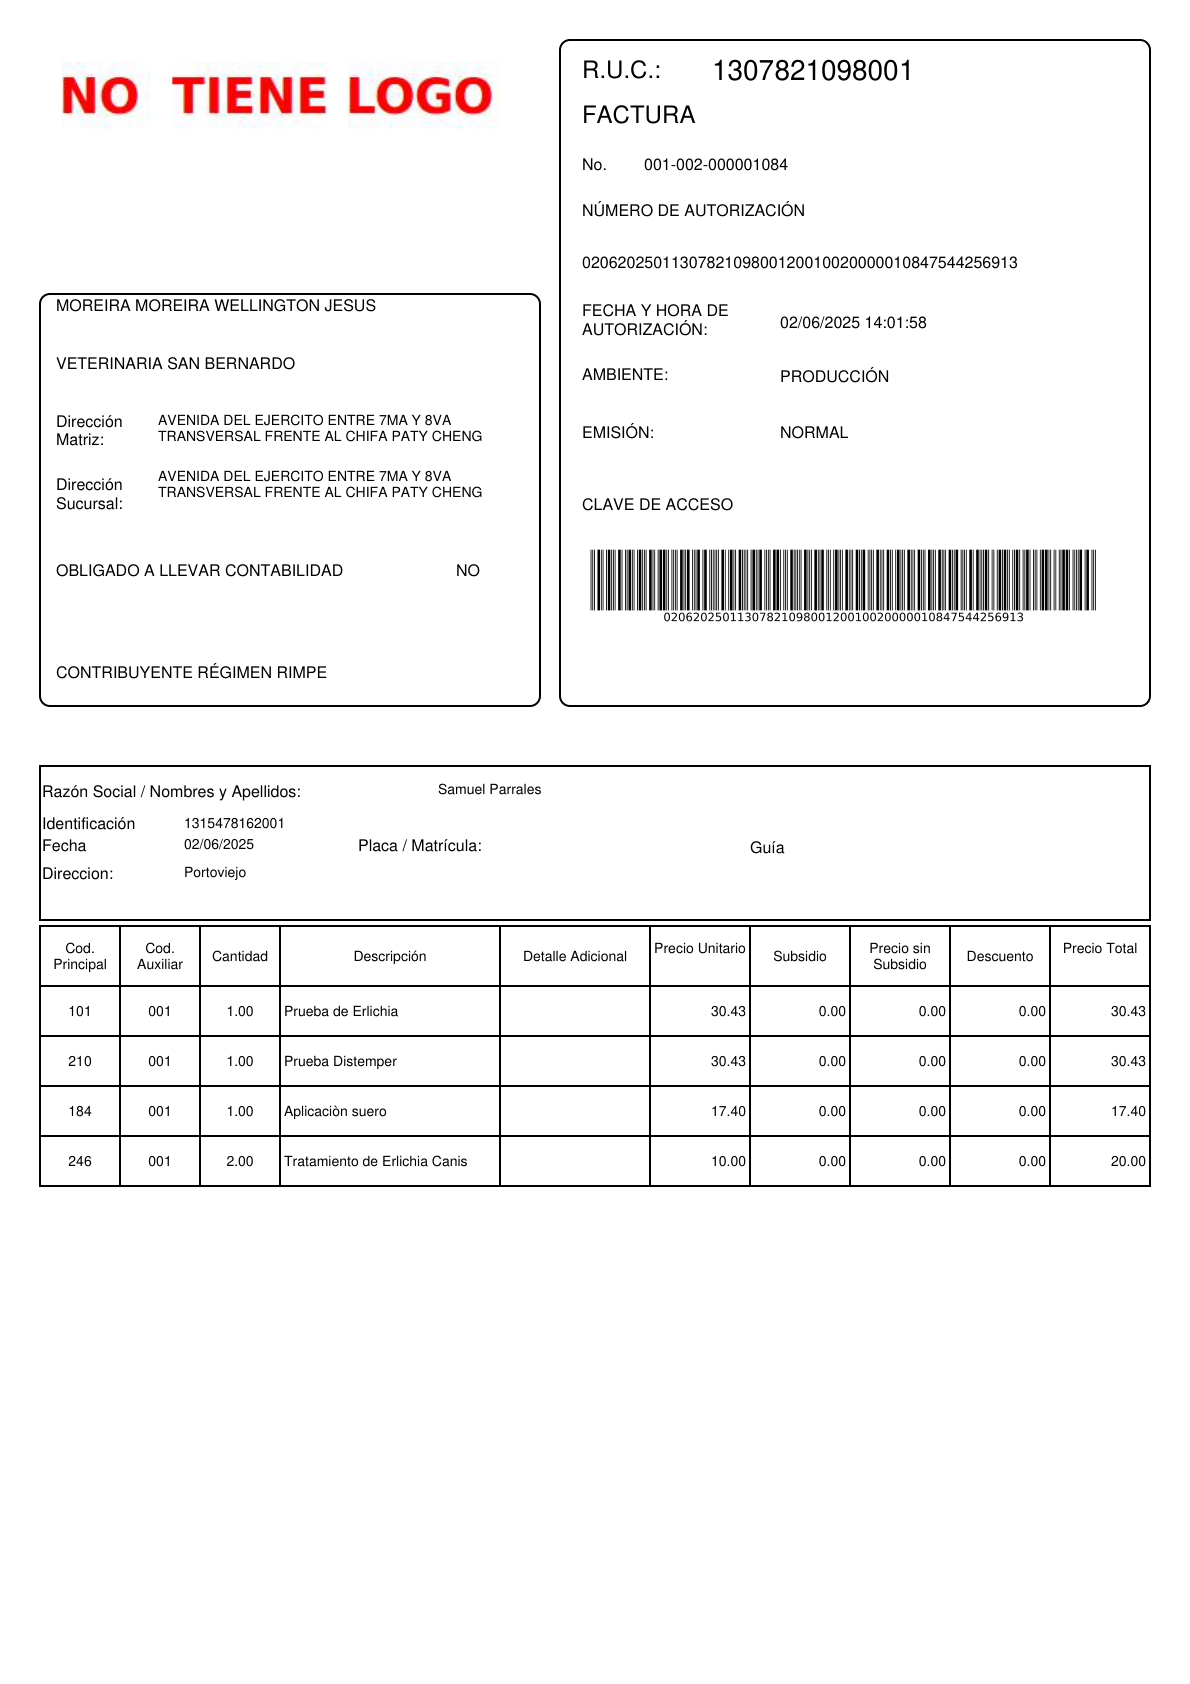

In [ ]:
if dataset and dataset[0].images:
    display(dataset[0].images[0])

In [ ]:
# Imprimir resumen de los primeros 10 PageSample
print(f"Total de PageSample: {len(dataset)}")
for id, sample in enumerate(dataset[:3], start=1):
    print(f"=== PageSample {id} ===")
    print(f"Imágenes cargadas: {len(sample.images)}")
    print(f"Cantidad de elementos: {len(sample.elements)}")
    print("Primeros elementos:", sample.elements[:2])  # Muestra solo los primeros 3 elementos para no saturar
    print("-" * 40)

Total de PageSample: 77
=== PageSample 1 ===
Imágenes cargadas: 1
Cantidad de elementos: 85
Primeros elementos: [{'label': 'FIELD_KEY_ID', 'text': 'R.U.C.:', 'source': 'digital', 'confidence': 1.0, 'page': 1, 'bbox': [291.0, 26.250022888183594, 330.33599853515625, 42.7380256652832], 'normalized_bbox': [489, 31, 555, 50]}, {'label': 'FIELD_VALUE_ID', 'text': '1105204364001', 'source': 'digital', 'confidence': 1.0, 'page': 1, 'bbox': [356.0, 24.79997444152832, 457.19195556640625, 44.03597640991211], 'normalized_bbox': [598, 29, 768, 52]}]
----------------------------------------
=== PageSample 2 ===
Imágenes cargadas: 1
Cantidad de elementos: 108
Primeros elementos: [{'label': 'FIELD_KEY_ID', 'text': 'R.U.C.:', 'source': 'digital', 'confidence': 1.0, 'page': 1, 'bbox': [291.0, 26.250022888183594, 330.33599853515625, 42.7380256652832], 'normalized_bbox': [489, 31, 555, 50]}, {'label': 'FIELD_VALUE_ID', 'text': '1790016919001', 'source': 'digital', 'confidence': 1.0, 'page': 1, 'bbox': [35

# Etiquetas

In [ ]:
all_labels = set()
for doc in dataset:
    for e in doc.elements:
        all_labels.add(e["label"])

label_list = sorted(list(all_labels))
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

print(f"Total etiquetas: {len(label_list)}")
print(f"Etiquetas: {label_list}")
print(f"ID de cada etiqueta: {id2label}")


Total etiquetas: 35
Etiquetas: ['FIELD_KEY_ADDRESS', 'FIELD_KEY_AMOUNT', 'FIELD_KEY_DATE', 'FIELD_KEY_EMAIL', 'FIELD_KEY_ID', 'FIELD_KEY_NAME', 'FIELD_KEY_TEXT', 'FIELD_VALUE_ADDRESS', 'FIELD_VALUE_AMOUNT', 'FIELD_VALUE_DATE', 'FIELD_VALUE_EMAIL', 'FIELD_VALUE_ID', 'FIELD_VALUE_NAME', 'FIELD_VALUE_TEXT', 'HEADER_PRODUCT_CODE', 'HEADER_PRODUCT_CODE_AUX', 'HEADER_PRODUCT_DETAIL', 'HEADER_PRODUCT_DISCOUNT', 'HEADER_PRODUCT_NAME', 'HEADER_PRODUCT_PRICE', 'HEADER_PRODUCT_QUANTITY', 'HEADER_PRODUCT_SUBSIDY', 'HEADER_PRODUCT_TOTAL', 'HEADER_PRODUCT_WITHOUT_SUBSIDY', 'ITEM_PRODUCT_CODE', 'ITEM_PRODUCT_CODE_AUX', 'ITEM_PRODUCT_DETAIL', 'ITEM_PRODUCT_DISCOUNT', 'ITEM_PRODUCT_NAME', 'ITEM_PRODUCT_PRICE', 'ITEM_PRODUCT_QUANTITY', 'ITEM_PRODUCT_SUBSIDY', 'ITEM_PRODUCT_TOTAL', 'ITEM_PRODUCT_WITHOUT_SUBSIDY', 'O']
ID de cada etiqueta: {0: 'FIELD_KEY_ADDRESS', 1: 'FIELD_KEY_AMOUNT', 2: 'FIELD_KEY_DATE', 3: 'FIELD_KEY_EMAIL', 4: 'FIELD_KEY_ID', 5: 'FIELD_KEY_NAME', 6: 'FIELD_KEY_TEXT', 7: 'FIELD_VALUE_

## Preprocesamiento para finetunning de acuerdo con el formato de LayoutMLv3

labels = [label2id[e["label"]] for e in elements]

Convierte la etiqueta de texto del elemento (por ejemplo, "HEADER", "QUESTION", "ANSWER") a su correspondiente ID numérico entero utilizando un diccionario de mapeo (label2id, como {"HEADER": 0, "QUESTION": 1, ...}).

Esto es indispensable para tareas de Token Classification o Layout Analysis en PyTorch/Hugging Face, ya que las funciones de pérdida (loss functions) requieren IDs numéricos como etiquetas target.

In [ ]:
def prepare_document(elements):
    words = [e["text"] for e in elements]
    boxes = [e["normalized_bbox"] for e in elements]
    labels = [label2id[e["label"]] for e in elements]
    return words, boxes, labels

def encode_document(image:Image.Image,elements: list[LayoutElement]):
    words, boxes, labels = prepare_document(elements)

    encoding = processor(
        images=image,
        text=words,
        boxes=boxes,
        word_labels=labels,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )
    return encoding



# Fine tunning de LayoutMLv3

Descargamos el modelo con sus pesos a traves de hugging face y utilizamos el Tokenizer y la transformacion a tensores de imagenes.

In [ ]:
from transformers import LayoutLMv3Processor

processor = LayoutLMv3Processor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Componentes y función exacta
from transformers import LayoutLMv3Processor
Importa la clase encargada de transformar los datos de entrada en bruto (imágenes de documentos, texto y las coordenadas de las cajas delimitadoras o bounding boxes) al formato numérico exacto (tensors) que el modelo LayoutLMv3 comprende.

from_pretrained("microsoft/layoutlmv3-base", ...)
Descarga (o carga desde la caché) la configuración de tokenización y procesamiento preconfigurada por Microsoft para la versión base de LayoutLMv3.

apply_ocr=False (El parámetro clave)
Indica al procesador que NO ejecute un motor de OCR automático (como Tesseract) sobre las imágenes pasadas al modelo.

Al usar apply_ocr=False: Debes proporcionarle manualmente al procesador tanto las palabras (words) como sus coordenadas o cajas delimitadoras (boxes), junto con las imágenes. Esto es común cuando ya cuentas con un dataset anotado o cuando usas un motor de OCR externo personalizado.

Si fuera True: El procesador intentaría extraer el texto y las coordenadas directamente de las imágenes de forma automática.

In [ ]:
from transformers import LayoutLMv3ForTokenClassification, TrainingArguments, Trainer
import torch

model = LayoutLMv3ForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.out_proj.bias   | MISSING | 
classifier.dense.weight    | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.dense.bias      | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Creacion del Dataset de Pytorch y Lazy loading para el manejo de multiples imagenes y optimizacion de memoria durante el entrenamiento.

In [ ]:
from torch.utils.data import Dataset as TorchDataset

def extract_per_page(page:PageSample):
    separated = []
    for index,image in enumerate(page.images):
        current_page = index + 1
        current_elements = [e for e in page.elements if e["page"] == current_page]
        separated.append((image, current_elements))
    return separated

class InvoiceDataset(TorchDataset):
    def __init__(self, documents):
        self.documents = documents

    def __getitem__(self, idx):
        image, elements = self.documents[idx]
        encoding = encode_document(image, elements)
        return {k: v.squeeze(0) for k, v in encoding.items()}

    def __len__(self):
        return len(self.documents)

split = int(len(dataset) * 0.8)

train_data = dataset[:split]
eval_data = dataset[split:]

train_data_final = []
for page in train_data:
    train_data_final.extend(extract_per_page(page))

eval_data_final = []
for page in eval_data:
    eval_data_final.extend(extract_per_page(page))


train_dataset = InvoiceDataset(train_data_final)
val_dataset = InvoiceDataset(eval_data_final)

print()
print(f"Train: {len(train_data)} | Val: {len(eval_data)}")
print(f"Train pages: {len(train_data_final)} | Val pages: {len(eval_data_final)}")


Train: 61 | Val: 16
Train pages: 93 | Val pages: 21


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from transformers import LayoutLMv3Processor


def preprocess_logits_for_metrics(logits, labels):
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.argmax(dim=-1)

def compute_metrics(p):
    predictions, labels = p

    true_predictions = [
        id2label[pred_id]
        for pred, lab in zip(predictions, labels)
        for (pred_id, l) in zip(pred, lab) if l != -100
    ]
    true_labels = [
        id2label[l]
        for pred, lab in zip(predictions, labels)
        for (pred_id, l) in zip(pred, lab) if l != -100
    ]

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, true_predictions, average="weighted", zero_division=0
    )
    acc = accuracy_score(true_labels, true_predictions)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": acc,
    }
training_args = TrainingArguments(
    output_dir="./model-output",
    num_train_epochs=10,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=5e-5,
    save_steps=50,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    eval_accumulation_steps=1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,

)

trainer.train()

trainer.save_model("./model-output/final")
processor.save_pretrained("./model-output/final")

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.972885,0.419163,0.967181,0.973995,0.968966,0.973995
2,0.157162,0.086504,0.993671,0.993499,0.993496,0.993499
3,0.092393,0.043304,0.995949,0.995863,0.995854,0.995863
4,0.049953,0.052089,0.993905,0.993499,0.993525,0.993499
5,0.028198,0.021158,0.998828,0.998818,0.998817,0.998818
6,0.019560,0.017161,0.998828,0.998818,0.998817,0.998818
7,0.014373,0.016961,0.998268,0.998227,0.998230,0.998227
8,0.016896,0.015560,0.998231,0.998227,0.998226,0.998227
9,0.011774,0.016312,0.997636,0.997636,0.997636,0.997636
10,0.020349,0.017281,0.997636,0.997636,0.997636,0.997636


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['./model-output/final/processor_config.json']

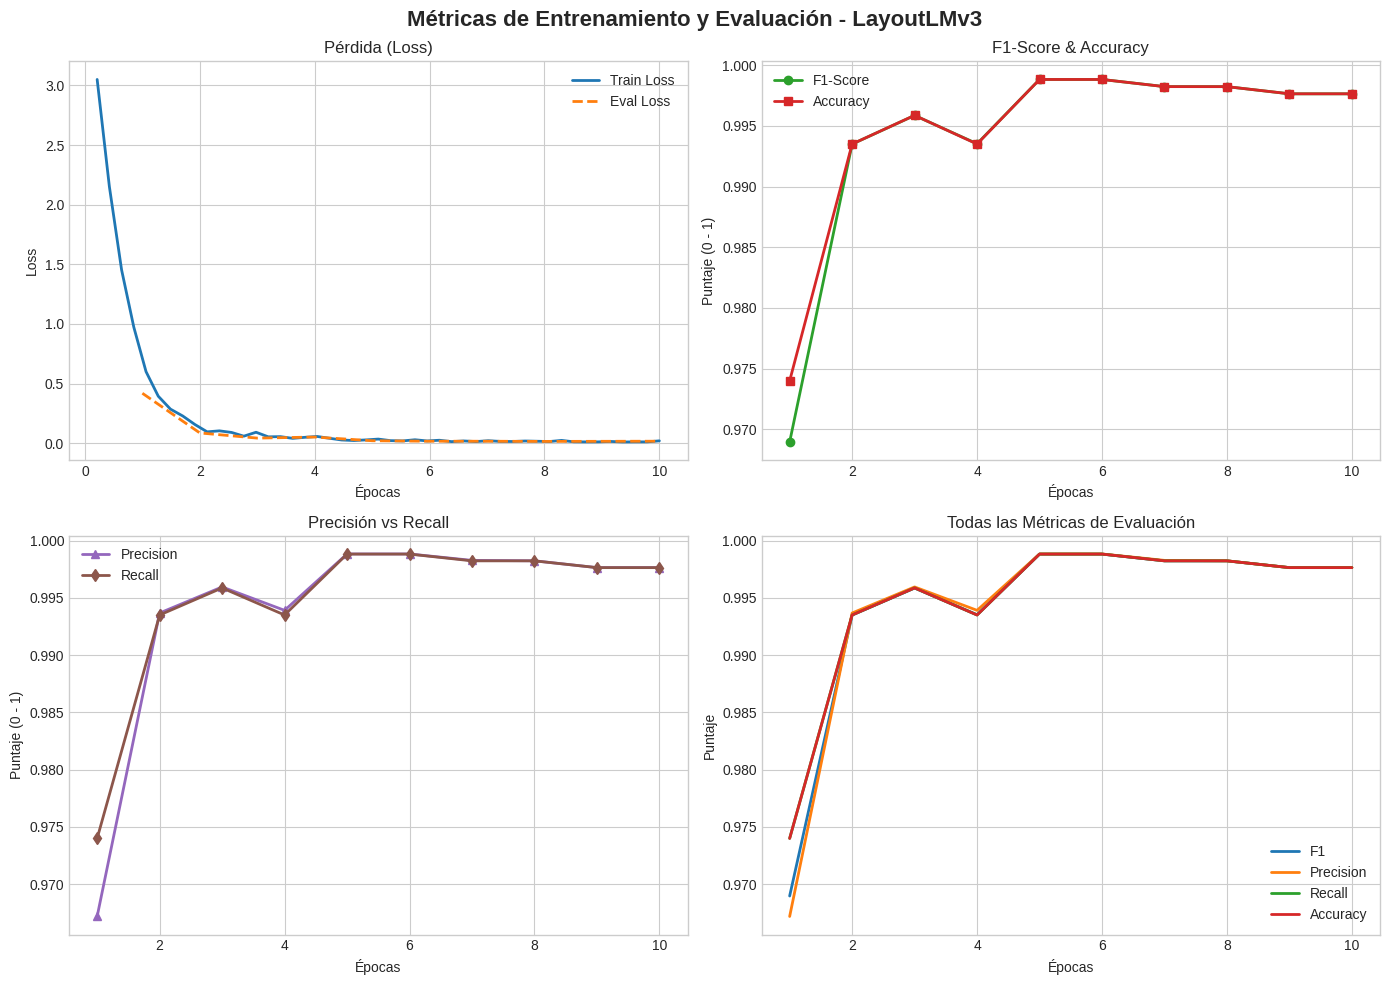

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extraer el historial de registros del Trainer
logs = trainer.state.log_history

# 2. Procesar los registros en estructuras de datos claras
train_logs = []
eval_logs = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_logs.append({"epoch": log["epoch"], "train_loss": log["loss"]})
    if "eval_loss" in log and "epoch" in log:
        eval_logs.append({
            "epoch": log["epoch"],
            "eval_loss": log["eval_loss"],
            "precision": log.get("eval_precision", 0),
            "recall": log.get("eval_recall", 0),
            "f1": log.get("eval_f1", 0),
            "accuracy": log.get("eval_accuracy", 0)
        })

# Convertir a DataFrames de Pandas
df_train = pd.DataFrame(train_logs)
df_eval = pd.DataFrame(eval_logs)

# 3. Configurar y generar las gráficas
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Métricas de Entrenamiento y Evaluación - LayoutLMv3", fontsize=16, fontweight="bold")

# Gráfica 1: Pérdida (Loss)
axes[0, 0].plot(df_train["epoch"], df_train["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
axes[0, 0].plot(df_eval["epoch"], df_eval["eval_loss"], label="Eval Loss", color="#ff7f0e", linewidth=2, linestyle="--")
axes[0, 0].set_title("Pérdida (Loss)")
axes[0, 0].set_xlabel("Épocas")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Gráfica 2: F1-Score y Accuracy
axes[0, 1].plot(df_eval["epoch"], df_eval["f1"], label="F1-Score", color="#2ca02c", linewidth=2, marker="o")
axes[0, 1].plot(df_eval["epoch"], df_eval["accuracy"], label="Accuracy", color="#d62728", linewidth=2, marker="s")
axes[0, 1].set_title("F1-Score & Accuracy")
axes[0, 1].set_xlabel("Épocas")
axes[0, 1].set_ylabel("Puntaje (0 - 1)")
axes[0, 1].legend()

# Gráfica 3: Precisión y Recall
axes[1, 0].plot(df_eval["epoch"], df_eval["precision"], label="Precision", color="#9467bd", linewidth=2, marker="^")
axes[1, 0].plot(df_eval["epoch"], df_eval["recall"], label="Recall", color="#8c564b", linewidth=2, marker="d")
axes[1, 0].set_title("Precisión vs Recall")
axes[1, 0].set_xlabel("Épocas")
axes[1, 0].set_ylabel("Puntaje (0 - 1)")
axes[1, 0].legend()

# Gráfica 4: Resumen de todas las métricas de evaluación
axes[1, 1].plot(df_eval["epoch"], df_eval["f1"], label="F1", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["precision"], label="Precision", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["recall"], label="Recall", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["accuracy"], label="Accuracy", linewidth=2)
axes[1, 1].set_title("Todas las Métricas de Evaluación")
axes[1, 1].set_xlabel("Épocas")
axes[1, 1].set_ylabel("Puntaje")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("./model-output/metricas_entrenamiento.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
from tabulate import tabulate

# 1. Imprimir la estructura interna de capas del modelo
print("=== ARQUITECTURA INTERNA DEL MODELO LAYOUTLMV3 ===")
print(model)

# 2. Calcular los parámetros totales y entrenables
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal de parámetros: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

# 3. Desglose de parámetros por módulo principal
layer_data = []
for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    layer_data.append([name, module.__class__.__name__, f"{params:,}"])

df_layers = pd.DataFrame(layer_data, columns=["Módulo", "Tipo de Capa", "Parámetros"])
print("\n=== DESGLOSE DE PARÁMETROS POR MÓDULO PRINCIPAL ===")
print(tabulate(df_layers, headers="keys", tablefmt="psql"))

=== ARQUITECTURA INTERNA DEL MODELO LAYOUTLMV3 ===
LayoutLMv3ForTokenClassification(
  (layoutlmv3): LayoutLMv3Model(
    (embeddings): LayoutLMv3TextEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (x_position_embeddings): Embedding(1024, 128)
      (y_position_embeddings): Embedding(1024, 128)
      (h_position_embeddings): Embedding(1024, 128)
      (w_position_embeddings): Embedding(1024, 128)
    )
    (patch_embed): LayoutLMv3PatchEmbeddings(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (norm): LayerNorm((768,), eps=1e-06, elemen

In [ ]:
!pip install torchinfo -q

In [ ]:
import torch
from torchinfo import summary

# 1. Detectar automáticamente si el modelo está en GPU o CPU
device = next(model.parameters()).device

# 2. Crear los tensores dummy y enviarlos AL MISMO dispositivo
dummy_input = {
    "input_ids": torch.zeros((1, 512), dtype=torch.long, device=device),
    "attention_mask": torch.ones((1, 512), dtype=torch.long, device=device),
    "bbox": torch.zeros((1, 512, 4), dtype=torch.long, device=device),
    "pixel_values": torch.zeros((1, 3, 224, 224), dtype=torch.float32, device=device),
}

# 3. Generar el resumen
summary(model, input_data=dummy_input, depth=3)

Layer (type:depth-idx)                                       Output Shape              Param #
LayoutLMv3ForTokenClassification                             [1, 512, 35]              --
├─LayoutLMv3Model: 1-1                                       [1, 709, 768]             152,064
│    └─LayoutLMv3TextEmbeddings: 2-1                         [1, 512, 768]             39,524,864
│    └─LayoutLMv3PatchEmbeddings: 2-2                        [1, 196, 768]             590,592
│    └─Dropout: 2-3                                          [1, 197, 768]             --
│    └─LayerNorm: 2-4                                        [1, 197, 768]             1,536
│    └─LayerNorm: 2-5                                        [1, 709, 768]             1,536
│    └─Dropout: 2-6                                          [1, 709, 768]             --
│    └─LayoutLMv3Encoder: 2-7                                [1, 709, 768]             85,056,384
├─Dropout: 1-2                                               [1

In [ ]:
import torch
from torchinfo import summary

# 1. Detectar automáticamente si el modelo está en GPU o CPU
device = next(model.parameters()).device

# 2. Crear los tensores dummy y enviarlos AL MISMO dispositivo
dummy_input = {
    "input_ids": torch.zeros((1, 512), dtype=torch.long, device=device),
    "attention_mask": torch.ones((1, 512), dtype=torch.long, device=device),
    "bbox": torch.zeros((1, 512, 4), dtype=torch.long, device=device),
    "pixel_values": torch.zeros((1, 3, 224, 224), dtype=torch.float32, device=device),
}

# 3. Generar el resumen
summary(model, input_data=dummy_input, depth=3)

Layer (type:depth-idx)                                       Output Shape              Param #
LayoutLMv3ForTokenClassification                             [1, 512, 35]              --
├─LayoutLMv3Model: 1-1                                       [1, 709, 768]             152,064
│    └─LayoutLMv3TextEmbeddings: 2-1                         [1, 512, 768]             --
│    │    └─Embedding: 3-1                                   [1, 512, 768]             38,603,520
│    │    └─Embedding: 3-2                                   [1, 512, 768]             768
│    │    └─Embedding: 3-3                                   [1, 512, 768]             394,752
│    │    └─Embedding: 3-4                                   [1, 512, 128]             131,072
│    │    └─Embedding: 3-5                                   [1, 512, 128]             131,072
│    │    └─Embedding: 3-6                                   [1, 512, 128]             (recursive)
│    │    └─Embedding: 3-7                               

# Verificacion de la tokenizacion

1. RESUMEN DE TENSORES (ENCODING DUPLE)
• input_ids      : Tipo=Tensor       | Forma=[1, 512] | Dtype=torch.int64
• attention_mask : Tipo=Tensor       | Forma=[1, 512] | Dtype=torch.int64
• bbox           : Tipo=Tensor       | Forma=[1, 512, 4] | Dtype=torch.int64
• labels         : Tipo=Tensor       | Forma=[1, 512] | Dtype=torch.int64
• pixel_values   : Tipo=Tensor       | Forma=[1, 3, 224, 224] | Dtype=torch.float32

2. MUESTRA DE TOKENIZACIÓN ALINEADA (Primeros 30 Tokens)
 Posición Token  Label ID        Etiqueta Bounding Box [x0,y0,x1,y1]  Attention Mask
        0   <s>      -100 IGNORADO (-100)               [0, 0, 0, 0]               1
        1    ĠR         4    FIELD_KEY_ID         [489, 31, 555, 50]               1
        2     .      -100 IGNORADO (-100)         [489, 31, 555, 50]               1
        3     U      -100 IGNORADO (-100)         [489, 31, 555, 50]               1
        4     .      -100 IGNORADO (-100)         [489, 31, 555, 50]               1
        5

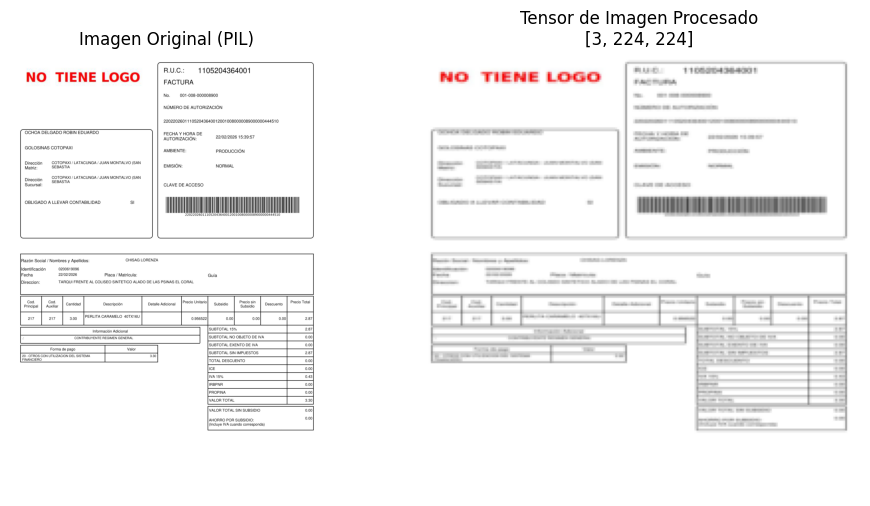

In [ ]:
import torch
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# 1. Seleccionar una página específica de prueba (por ejemplo, la primera de entrenamiento)
sample_image, sample_elements = train_data_final[0]

# 2. Generar el encoding crudo llamando a la función encode_document
encoding = encode_document(sample_image, sample_elements)

# 3. Extraer tensores individuales (descomprimiendo la dimensión batch con .squeeze(0))
input_ids = encoding["input_ids"].squeeze(0)
attention_mask = encoding["attention_mask"].squeeze(0)
bbox = encoding["bbox"].squeeze(0)
labels = encoding["labels"].squeeze(0)
pixel_values = encoding["pixel_values"].squeeze(0)

# 4. Decodificar los tokens de texto para inspección
tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)

# --- IMPRESIÓN 1: ESTRUCTURA Y FORMA DE LOS TENSORES ---
print("=" * 65)
print("1. RESUMEN DE TENSORES (ENCODING DUPLE)")
print("=" * 65)
for key, tensor in encoding.items():
    print(f"• {key:<15}: Tipo={type(tensor).__name__:<12} | Forma={list(tensor.shape)} | Dtype={tensor.dtype}")

# --- IMPRESIÓN 2: TABLA DE TOKENIZACIÓN Y ESPACIALIZACIÓN ---
print("\n" + "=" * 65)
print("2. MUESTRA DE TOKENIZACIÓN ALINEADA (Primeros 30 Tokens)")
print("=" * 65)

token_data = []
for i in range(min(30, len(tokens))):
    tok = tokens[i]
    lbl_id = labels[i].item()
    lbl_str = id2label.get(lbl_id, "IGNORADO/PADDING") if lbl_id != -100 else "IGNORADO (-100)"
    box = bbox[i].tolist()
    att = attention_mask[i].item()

    token_data.append([i, tok, lbl_id, lbl_str, box, att])

df_tokens = pd.DataFrame(token_data, columns=["Posición", "Token", "Label ID", "Etiqueta", "Bounding Box [x0,y0,x1,y1]", "Attention Mask"])
print(df_tokens.to_string(index=False))

# --- IMPRESIÓN 3: TENSORES DE IMAGEN Y VISUALIZACIÓN ---
print("\n" + "=" * 65)
print("3. INSPECCIÓN Y PREVISUALIZACIÓN DEL TENSOR DE IMAGEN")
print("=" * 65)
print(f"Tensor de Imagen (pixel_values): {pixel_values.shape} (Canales, Alto, Ancho)")
print(f"Rango de valores de píxel (normalizados): Mín={pixel_values.min():.2f}, Máx={pixel_values.max():.2f}")

# Reconstruir el tensor de la imagen normalizada para visualizarlo
# (Des-normalizar cambiando la forma [C, H, W] -> [H, W, C])
img_tensor_vis = pixel_values.permute(1, 2, 0).cpu().numpy()
# Normalizar al rango 0-1 para renderizado correcto en matplotlib
img_tensor_vis = (img_tensor_vis - img_tensor_vis.min()) / (img_tensor_vis.max() - img_tensor_vis.min())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(sample_image)
axes[0].set_title("Imagen Original (PIL)")
axes[0].axis("off")

axes[1].imshow(img_tensor_vis)
axes[1].set_title(f"Tensor de Imagen Procesado\n{list(pixel_values.shape)}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Extraer el tensor unidimensional de input_ids
raw_input_ids_tensor = encoding["input_ids"].squeeze(0)

# Convertir a lista nativa de Python
raw_input_ids_list = raw_input_ids_tensor.tolist()

print("=" * 65)
print("VECTOR DE TOKENS RAW (input_ids - Tensor PyTorch)")
print("=" * 65)
print(f"Forma del tensor: {raw_input_ids_tensor.shape}")
print(f"Tipo de dato: {raw_input_ids_tensor.dtype}")
print("\nContenido del Tensor:")
print(raw_input_ids_tensor)

print("\n" + "=" * 65)
print("VECTOR DE TOKENS RAW (Lista Python de Enteros)")
print("=" * 65)
print(raw_input_ids_list)

VECTOR DE TOKENS RAW (input_ids - Tensor PyTorch)
Forma del tensor: torch.Size([512])
Tipo de dato: torch.int64

Contenido del Tensor:
tensor([    0,   248,     4,   791,     4,   347, 12651,  8017, 31271,  3897,
         4027, 19089,  8228, 29079, 33978, 34772,   673,   274, 13709, 41018,
          440,     4, 16273,   134,    12, 37277,    12, 25034,  5046,   612,
          234,  3849, 15113, 26011,   673,  5885, 40015,  3411, 17045,  2562,
          100,  3849,  9085,   487, 14576, 16846,  2481,  2663, 11670, 31271,
         3897,  4027,   612, 36643,  1866,  3913,   151,  5046, 33413,  3305,
         1898,   698,   384,  3764, 16024, 16286,   534,  2606,   673, 31989,
         2444, 12714,   791, 11250,   673, 39731,  6826,   854, 37394,   250,
         5885, 40015,  3411, 17045,  2562,   100,  3849,  9085,   487,    35,
          820,    73,  4197,    73,   844,  2481,   379,    35,  3416,    35,
         4390,   272,  3384,  3196,  2444,  2336,   230,  3293,  5733, 26624,
       

1. DATOS RAW DEL DOCUMENTO DE ENTRADA
• Texto completo extraído (Raw Text): R.U.C.: 1105204364001 NO TIENE LOGO FACTURA No. 001-008-000008900 NÚMERO DE AUTORIZACIÓN 2202202601110520436400120010080000089000000444510 OCHOA DELGADO ROBIN EDUARDO FECHA Y HORA DE AUTORIZACIÓN: 22/02/2026 15:39:57 GOLOSINAS COTOPAXI AMBIENTE: PRODUCCIÓN Dirección Matriz: COTOPAXI / LATACUNGA / JUAN MONTALVO (SAN SEBASTIA EMISIÓN: NORMAL COTOPAXI / LATACUNGA / JUAN MONTALVO (SAN SEBASTIA Dirección Sucursal: CLAVE DE ACCESO OBLIGADO A LLEVAR CONTABILIDAD SI Razón Social / Nombres y Apellidos: CHISAG LORENZA Identificación 0200619096 Fecha 22/02/2026 Placa / Matrícula: Guía Direccion: TARQUI FRENTE AL COLISEO SINTETICO ALADO DE LAS PSINAS EL CORAL Cod. Principal Cod. Auxiliar Precio Unitario Precio sin Subsidio Precio Total Cantidad Descripción Detalle Adicional Subsidio Descuento PERLITA CARAMELO  40TX16U 217 217 3.00 0.956522 0.00 0.00 0.00 2.87 SUBTOTAL 15% 2.87 Información Adicional SUBTOTAL NO OBJETO DE IV

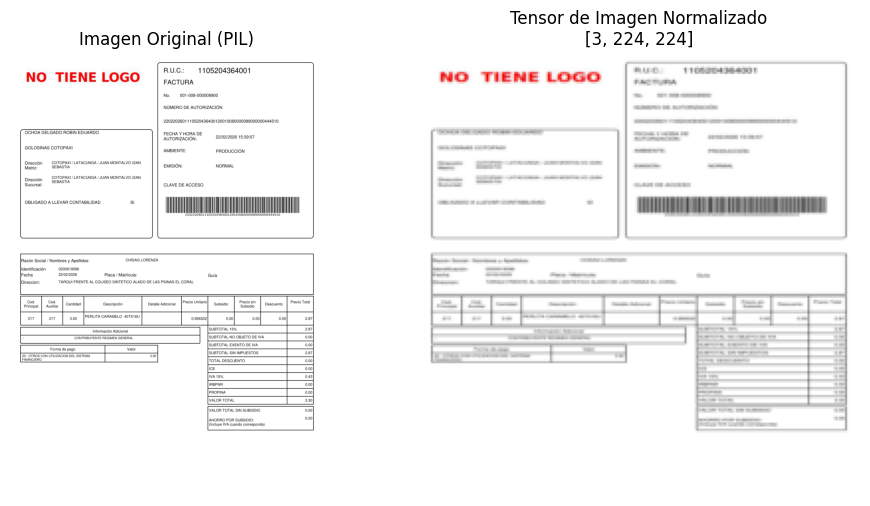

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

# 1. Seleccionar la muestra deseada de entrenamiento
sample_image, sample_elements = train_data_final[0]

# 2. Obtener el encoding completo
encoding = encode_document(sample_image, sample_elements)

# 3. Extraer tensores individuales (remover dimensión de batch)
input_ids = encoding["input_ids"].squeeze(0)
attention_mask = encoding["attention_mask"].squeeze(0)
bbox = encoding["bbox"].squeeze(0)
labels = encoding["labels"].squeeze(0)
pixel_values = encoding["pixel_values"].squeeze(0)

# 4. Decodificar tokens y preparar inspección
tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)

# --- A. INFORMACIÓN GENERAL Y RAW TEXT ---
raw_text = [e["text"] if isinstance(e, dict) else e.text for e in sample_elements]

print("=" * 85)
print("1. DATOS RAW DEL DOCUMENTO DE ENTRADA")
print("=" * 85)
print(f"• Texto completo extraído (Raw Text): {' '.join(raw_text)}")
print(f"• Cantidad de elementos/palabras originales: {len(sample_elements)}")
print(f"• Dimensiones de la imagen original (PIL): {sample_image.size} (Ancho x Alto)")

# --- B. VECTORES RAW DE ENTRADA AL MODELO ---
print("\n" + "=" * 85)
print("2. VECTORES RAW DE ENTRADA (TENSORES DE PYTORCH)")
print("=" * 85)
print(f"• Vector input_ids (Tokens ID): shape={list(input_ids.shape)}")
print(f"  {input_ids.tolist()[:25]}... [truncado]")

print(f"• Vector labels (IDs de Etiquetas): shape={list(labels.shape)}")
print(f"  {labels.tolist()[:25]}... [truncado]")

print(f"• Tensor pixel_values (Imagen): shape={list(pixel_values.shape)}")

# --- C. TABLA COMPARATIVA DETALLADA MUESTRA A MUESTRA ---
print("\n" + "=" * 85)
print("3. DESGLOSE TOKEN A TOKEN Y ALINEACIÓN CON METADATOS")
print("=" * 85)

detailed_data = []
for i in range(min(40, len(tokens))):  # Mostramos los primeros 40 tokens
    token_str = tokens[i]
    token_id = input_ids[i].item()
    mask_val = attention_mask[i].item()
    lbl_id = labels[i].item()

    # Mapear label ID a su nombre en texto
    if lbl_id != -100:
        label_name = id2label.get(lbl_id, f"ID_{lbl_id}")
    else:
        label_name = "PADDING / SUBTOKEN (-100)"

    box_coord = bbox[i].tolist()

    detailed_data.append([
        i,
        token_str,
        token_id,
        lbl_id,
        label_name,
        box_coord,
        mask_val
    ])

df_detail = pd.DataFrame(
    detailed_data,
    columns=["Pos", "Token", "Token ID (Raw)", "Label ID", "Etiqueta", "BBox [x0,y0,x1,y1]", "Attention Mask"]
)
print(df_detail.to_string(index=False))

# --- D. VISUALIZACIÓN DE LA IMAGEN CORTADA/PROCESADA ---
img_tensor_vis = pixel_values.permute(1, 2, 0).cpu().numpy()
img_tensor_vis = (img_tensor_vis - img_tensor_vis.min()) / (img_tensor_vis.max() - img_tensor_vis.min())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_image)
axes[0].set_title("Imagen Original (PIL)")
axes[0].axis("off")

axes[1].imshow(img_tensor_vis)
axes[1].set_title(f"Tensor de Imagen Normalizado\n{list(pixel_values.shape)}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("gpt2")
print(model.config)
print(model.generation_config)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": null,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.15.1",
  "use_cache": true,
  "vocab_size": 50257
}

GenerationConfig {
  "bos_t

1. INFORMACIÓN DE VISUAL PATCHES EN LAYOUTLMV3
• Dimensión de la imagen normalizada: 224 x 224 píxeles
• Tamaño de cada parche (patch_size): 16 x 16 píxeles
• Matriz de parches: 14 x 14
• Total de parches visuales generados: 196 parches


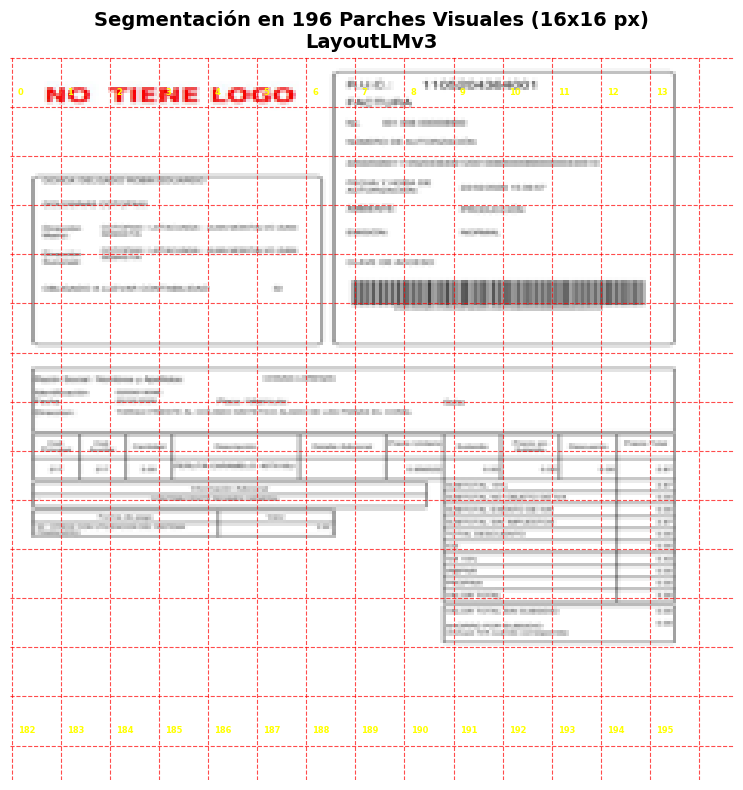

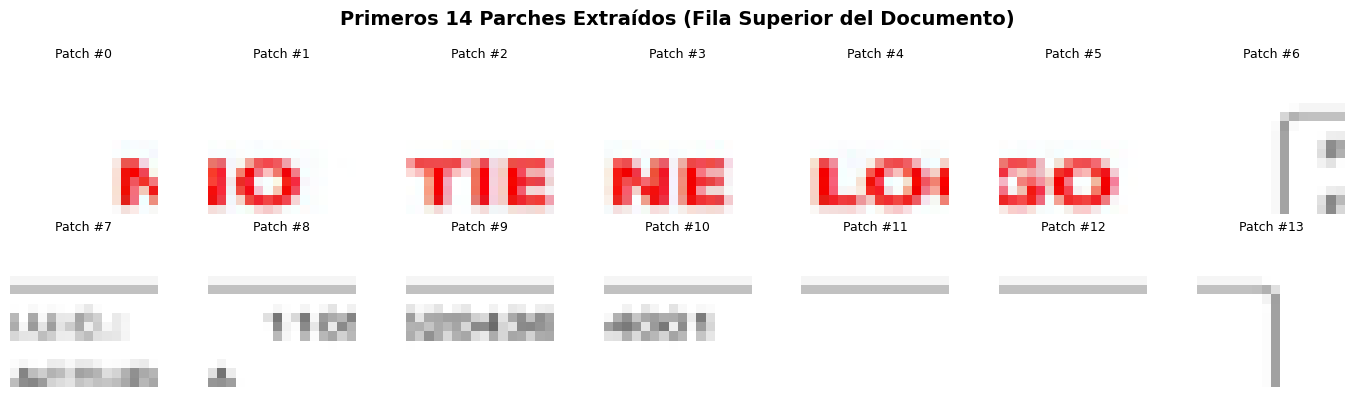

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Seleccionar un documento de prueba (por ejemplo, el primero)
sample_image, sample_elements = train_data_final[0]

# 2. Configurar dimensiones de LayoutLMv3
IMAGE_SIZE = (224, 224)
PATCH_SIZE = 16  # Tamaño estándar del parche en parches de visión ViT / LayoutLMv3

# Redimensionar la imagen como lo hace el LayoutLMv3Processor
img_resized = sample_image.resize(IMAGE_SIZE)
img_np = np.array(img_resized)

# 3. Calcular parches
num_patches_per_dim = IMAGE_SIZE[0] // PATCH_SIZE  # 224 / 16 = 14 parches por fila/columna
total_patches = num_patches_per_dim * num_patches_per_dim  # 14 x 14 = 196 visual patches

print("=" * 65)
print("1. INFORMACIÓN DE VISUAL PATCHES EN LAYOUTLMV3")
print("=" * 65)
print(f"• Dimensión de la imagen normalizada: {IMAGE_SIZE[0]} x {IMAGE_SIZE[1]} píxeles")
print(f"• Tamaño de cada parche (patch_size): {PATCH_SIZE} x {PATCH_SIZE} píxeles")
print(f"• Matriz de parches: {num_patches_per_dim} x {num_patches_per_dim}")
print(f"• Total de parches visuales generados: {total_patches} parches")

# --- GRAFICAR LA CUADRÍCULA DE PARCHES SOBRE LA IMAGEN ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_np)

# Dibujar las líneas divisorias de la retícula de parches
for i in range(0, IMAGE_SIZE[0] + 1, PATCH_SIZE):
    ax.axhline(i, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axvline(i, color="red", linestyle="--", linewidth=0.8, alpha=0.7)

# Numerar los primeros parches para entender la secuencia de ingesta
patch_idx = 0
for row in range(num_patches_per_dim):
    for col in range(num_patches_per_dim):
        x = col * PATCH_SIZE + 2
        y = row * PATCH_SIZE + 12
        # Numerar los primeros parches y los últimos
        if patch_idx < 14 or patch_idx >= total_patches - 14:
            ax.text(x, y, str(patch_idx), color="yellow", fontsize=6, fontweight="bold")
        patch_idx += 1

ax.set_title(f"Segmentación en {total_patches} Parches Visuales (16x16 px)\nLayoutLMv3", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

# --- MOSTRAR UNA MUESTRA DE PARCHES EXTRAÍDOS INDIVIDUALMENTE ---
fig, axes = plt.subplots(2, 7, figsize=(14, 4))
fig.suptitle("Primeros 14 Parches Extraídos (Fila Superior del Documento)", fontsize=14, fontweight="bold")

patch_count = 0
for col in range(num_patches_per_dim):
    # Recortar el parche específico
    y_start, y_end = 0 * PATCH_SIZE, (0 + 1) * PATCH_SIZE
    x_start, x_end = col * PATCH_SIZE, (col + 1) * PATCH_SIZE
    patch_crop = img_np[y_start:y_end, x_start:x_end]

    ax = axes[patch_count // 7, patch_count % 7]
    ax.imshow(patch_crop)
    ax.set_title(f"Patch #{patch_count}", fontsize=9)
    ax.axis("off")
    patch_count += 1

plt.tight_layout()
plt.show()

Generando predicciones sobre val_dataset...


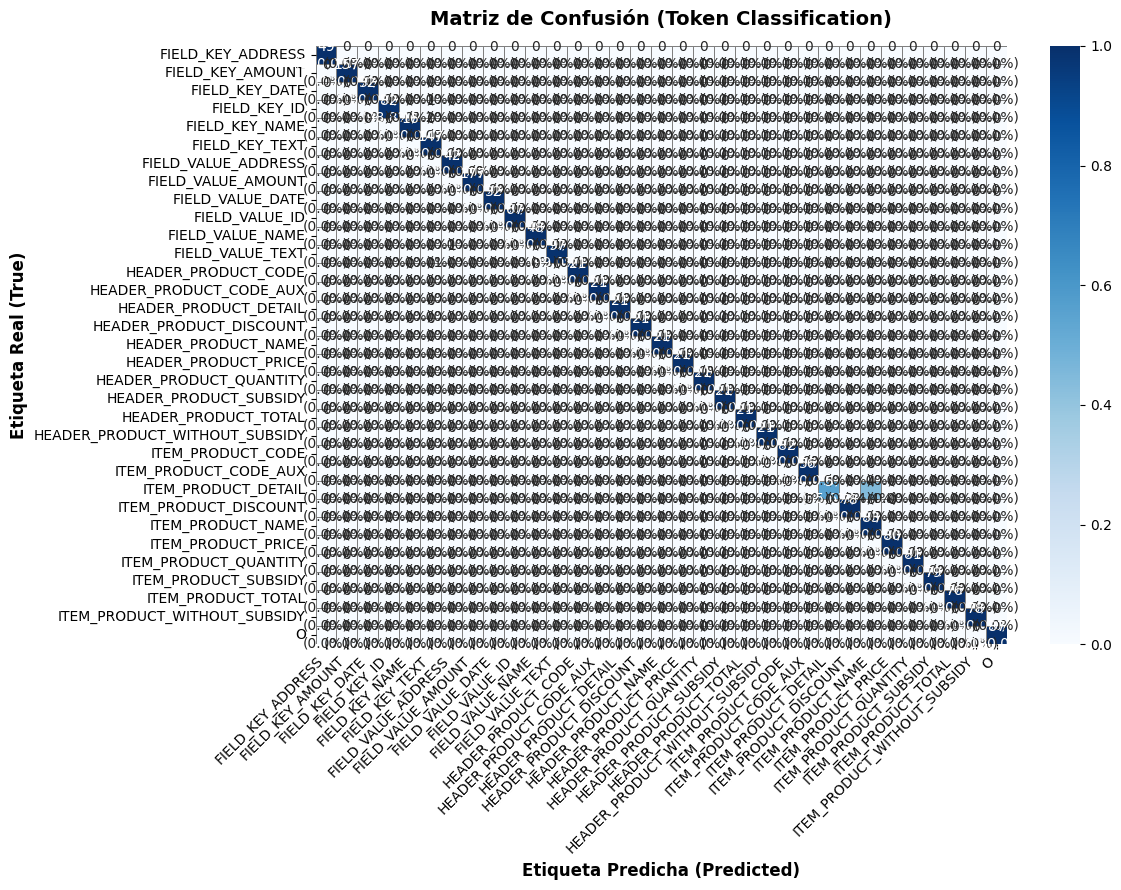


REPORTE DE CLASIFICACIÓN DETALLADO POR CLASE
                                precision    recall  f1-score   support

             FIELD_KEY_ADDRESS     1.0000    1.0000    1.0000        49
              FIELD_KEY_AMOUNT     1.0000    1.0000    1.0000       157
                FIELD_KEY_DATE     1.0000    1.0000    1.0000        32
                  FIELD_KEY_ID     1.0000    0.9880    0.9939        83
                FIELD_KEY_NAME     1.0000    1.0000    1.0000        16
                FIELD_KEY_TEXT     0.9932    1.0000    0.9966       147
           FIELD_VALUE_ADDRESS     0.9767    1.0000    0.9882        42
            FIELD_VALUE_AMOUNT     1.0000    1.0000    1.0000       177
              FIELD_VALUE_DATE     1.0000    1.0000    1.0000        32
                FIELD_VALUE_ID     1.0000    1.0000    1.0000        67
              FIELD_VALUE_NAME     1.0000    1.0000    1.0000        48
              FIELD_VALUE_TEXT     1.0000    0.9898    0.9949        98
           HEADER

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener las predicciones del modelo sobre el conjunto de validación/evaluación
print("Generando predicciones sobre val_dataset...")
raw_predictions = trainer.predict(val_dataset)

# 2. Extraer predicciones (IDs) y etiquetas reales
# raw_predictions.predictions ya tiene el .argmax() si usaste preprocess_logits_for_metrics
predictions = raw_predictions.predictions
labels = raw_predictions.label_ids

# Si predictions es una tupla, tomamos el primer elemento
if isinstance(predictions, tuple):
    predictions = predictions[0]

# Si por alguna razón los logits no se procesaron con argmax, aplicarlo aquí:
if len(predictions.shape) == 3:
    predictions = np.argmax(predictions, axis=-1)

# 3. Filtrar los tokens ignorados (-100) y obtener listas unidimensionales
true_labels_flat = []
pred_labels_flat = []

for pred_seq, label_seq in zip(predictions, labels):
    for pred_id, label_id in zip(pred_seq, label_seq):
        if label_id != -100:
            # Convertir IDs numéricos a sus cadenas de texto
            true_labels_flat.append(id2label[label_id])
            pred_labels_flat.append(id2label[pred_id])

# 4. Obtener la lista única de clases presentes en el conjunto de evaluación (ordenadas)
classes = sorted(list(set(true_labels_flat + pred_labels_flat)))

# 5. Calcular la Matriz de Confusión
cm = confusion_matrix(true_labels_flat, pred_labels_flat, labels=classes)

# -------------------------------------------------------------------------
# VISUALIZACIÓN 1: Matriz de Confusión (Valores Absolutos y Porcentajes)
# -------------------------------------------------------------------------
plt.figure(figsize=(12, 9))

# Calcular porcentajes por fila (normalización por clase real)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.nan_to_num(cm_normalized) # Manejar divisiones por cero si existen

# Crear anotaciones combinadas: "Cantidad \n (Porcentaje%)"
annot_matrix = np.empty(cm.shape, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm_normalized[i, j] * 100
        annot_matrix[i, j] = f"{count}\n({percent:.1f}%)"

# Graficar Mapa de Calor
sns.heatmap(
    cm_normalized,
    annot=annot_matrix,
    fmt="",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    cbar=True,
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Matriz de Confusión (Token Classification)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Etiqueta Predicha (Predicted)", fontsize=12, fontweight="bold")
plt.ylabel("Etiqueta Real (True)", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# VISUALIZACIÓN 2: Reporte de Clasificación Detallado por Clase
# -------------------------------------------------------------------------
print("\n" + "=" * 80)
print("REPORTE DE CLASIFICACIÓN DETALLADO POR CLASE")
print("=" * 80)
report = classification_report(true_labels_flat, pred_labels_flat, target_names=classes, digits=4, zero_division=0)
print(report)

# Congelamiento de las capas del modelo base

In [ ]:
model_freeze = LayoutLMv3ForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.out_proj.bias   | MISSING | 
classifier.dense.weight    | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.dense.bias      | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch

# 1. Congelar TODOS los parámetros del modelo base (LayoutLMv3Model)
for param in model_freeze.layoutlmv3.parameters():
    param.requires_grad = False

# 2. Asegurar que la cabeza de clasificación (classifier) permanezca ENTRENABLE
for param in model_freeze.classifier.parameters():
    param.requires_grad = True

# 3. Verificación de parámetros entrenables vs congelados
trainable_params = sum(p.numel() for p in model_freeze.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_freeze.parameters())
frozen_params = total_params - trainable_params

print("=" * 60)
print("ESTADO DE PARÁMETROS TRAS EL CONGELAMIENTO")
print("=" * 60)
print(f"• Parámetros Totales:      {total_params:,}")
print(f"• Parámetros Congelados:   {frozen_params:,} ({frozen_params/total_params*100:.2f}%)")
print(f"• Parámetros Entrenables:  {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")



ESTADO DE PARÁMETROS TRAS EL CONGELAMIENTO
• Parámetros Totales:      125,944,483
• Parámetros Congelados:   125,326,976 (99.51%)
• Parámetros Entrenables:  617,507 (0.49%)


In [ ]:
training_args = TrainingArguments(
    output_dir="./layoutlmv3-frozen-output",
    num_train_epochs=15,                    # Se incrementa ligeramente ya que entrena rápido
    per_device_train_batch_size=4,          # Aumentado a 4 aprovechando la reducción de VRAM
    per_device_eval_batch_size=4,
    learning_rate=1e-3,                     # LR más alto (1e-3) adecuado para entrenar solo la cabeza lineal
    weight_decay=0.01,                      # Regularización L2 sobre la capa de clasificación
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",             # Carga el mejor modelo basado en el F1-Score
    greater_is_better=True,
    eval_accumulation_steps=1,
    report_to="none"                        # Cambiar a "wandb" o "tensorboard" si se requiere
)

trainer = Trainer(
    model=model_freeze,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,
)

# Iniciar el entrenamiento
print("Iniciando entrenamiento con el backbone congelado...")
trainer.train()

# Guardar el modelo y el preprocesador final
trainer.save_model("./layoutlmv3-frozen-best")
processor.save_pretrained("./layoutlmv3-frozen-best")
print("\n¡Entrenamiento finalizado y modelo guardado en './layoutlmv3-frozen-best'!")

Iniciando entrenamiento con el backbone congelado...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,1.014524,0.414172,0.924690,0.916667,0.915295,0.916667
2,0.301884,0.180355,0.965006,0.962766,0.962939,0.962766
3,0.157864,0.117367,0.978287,0.976950,0.977039,0.976950
4,0.109314,0.086114,0.981152,0.980496,0.980578,0.980496
5,0.084423,0.072898,0.984007,0.983452,0.983534,0.983452
6,0.073419,0.064272,0.986130,0.985816,0.985808,0.985816
7,0.059718,0.058822,0.988367,0.988180,0.988176,0.988180
8,0.058555,0.058806,0.987333,0.986998,0.986995,0.986998
9,0.042603,0.055125,0.988631,0.988180,0.988119,0.988180
10,0.041175,0.048895,0.989677,0.989362,0.989387,0.989362


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


¡Entrenamiento finalizado y modelo guardado en './layoutlmv3-frozen-best'!


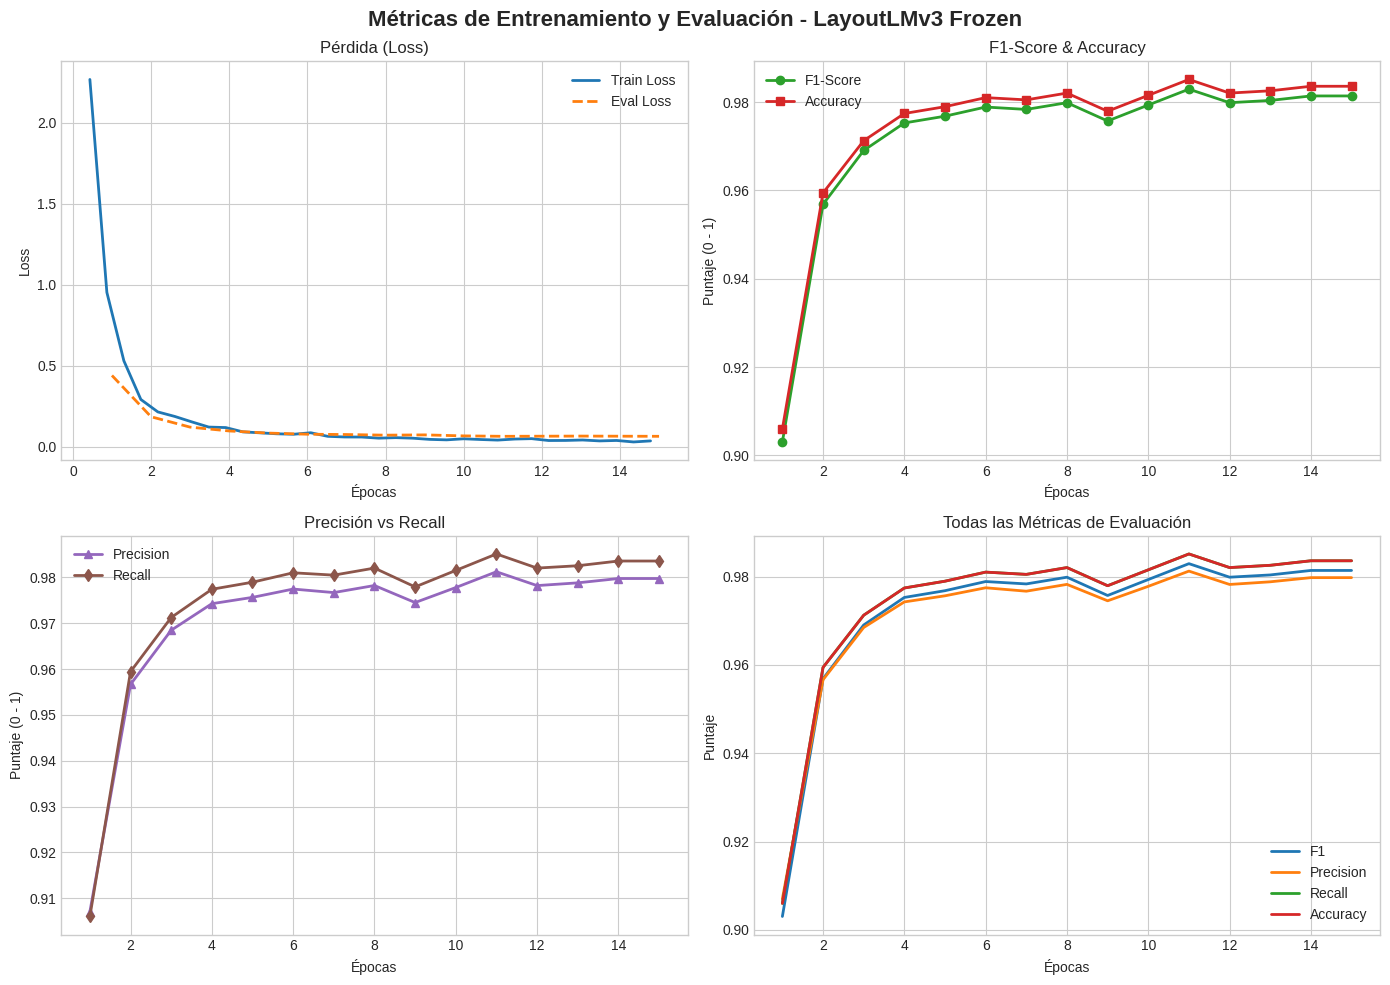

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extraer el historial de registros del Trainer
logs = trainer.state.log_history

# 2. Procesar los registros en estructuras de datos claras
train_logs = []
eval_logs = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_logs.append({"epoch": log["epoch"], "train_loss": log["loss"]})
    if "eval_loss" in log and "epoch" in log:
        eval_logs.append({
            "epoch": log["epoch"],
            "eval_loss": log["eval_loss"],
            "precision": log.get("eval_precision", 0),
            "recall": log.get("eval_recall", 0),
            "f1": log.get("eval_f1", 0),
            "accuracy": log.get("eval_accuracy", 0)
        })

# Convertir a DataFrames de Pandas
df_train = pd.DataFrame(train_logs)
df_eval = pd.DataFrame(eval_logs)

# 3. Configurar y generar las gráficas
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Métricas de Entrenamiento y Evaluación - LayoutLMv3 Frozen", fontsize=16, fontweight="bold")

# Gráfica 1: Pérdida (Loss)
axes[0, 0].plot(df_train["epoch"], df_train["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
axes[0, 0].plot(df_eval["epoch"], df_eval["eval_loss"], label="Eval Loss", color="#ff7f0e", linewidth=2, linestyle="--")
axes[0, 0].set_title("Pérdida (Loss)")
axes[0, 0].set_xlabel("Épocas")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Gráfica 2: F1-Score y Accuracy
axes[0, 1].plot(df_eval["epoch"], df_eval["f1"], label="F1-Score", color="#2ca02c", linewidth=2, marker="o")
axes[0, 1].plot(df_eval["epoch"], df_eval["accuracy"], label="Accuracy", color="#d62728", linewidth=2, marker="s")
axes[0, 1].set_title("F1-Score & Accuracy")
axes[0, 1].set_xlabel("Épocas")
axes[0, 1].set_ylabel("Puntaje (0 - 1)")
axes[0, 1].legend()

# Gráfica 3: Precisión y Recall
axes[1, 0].plot(df_eval["epoch"], df_eval["precision"], label="Precision", color="#9467bd", linewidth=2, marker="^")
axes[1, 0].plot(df_eval["epoch"], df_eval["recall"], label="Recall", color="#8c564b", linewidth=2, marker="d")
axes[1, 0].set_title("Precisión vs Recall")
axes[1, 0].set_xlabel("Épocas")
axes[1, 0].set_ylabel("Puntaje (0 - 1)")
axes[1, 0].legend()

# Gráfica 4: Resumen de todas las métricas de evaluación
axes[1, 1].plot(df_eval["epoch"], df_eval["f1"], label="F1", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["precision"], label="Precision", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["recall"], label="Recall", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["accuracy"], label="Accuracy", linewidth=2)
axes[1, 1].set_title("Todas las Métricas de Evaluación")
axes[1, 1].set_xlabel("Épocas")
axes[1, 1].set_ylabel("Puntaje")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("./layoutlmv3-frozen-output/metricas_entrenamiento.png", dpi=300)
plt.show()

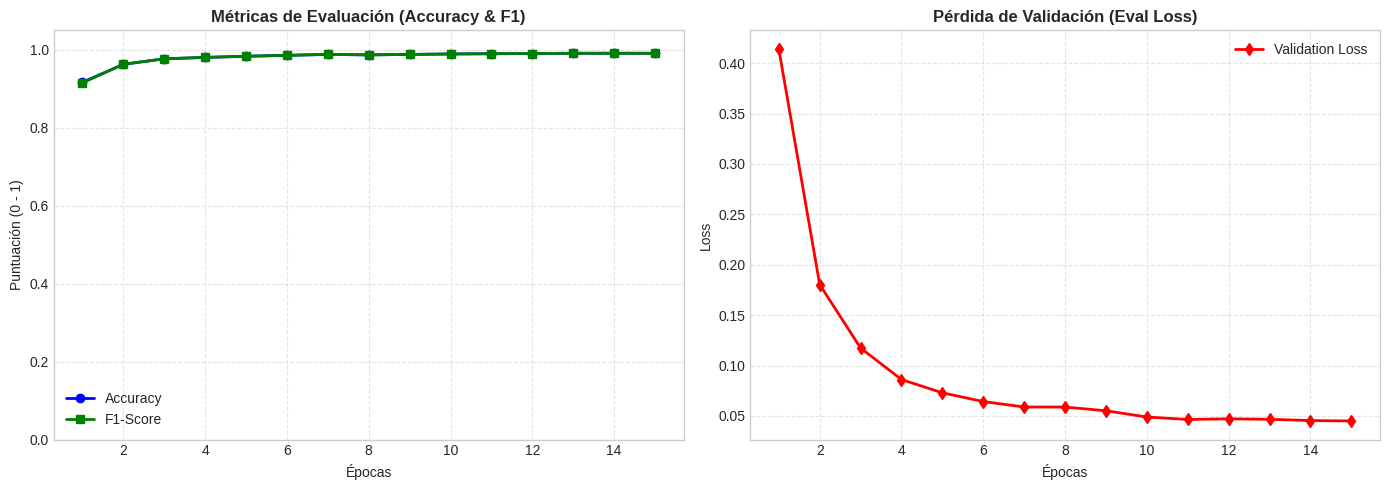

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraer registros de evaluación
df_metrics = pd.DataFrame([
    {
        "epoch": e["epoch"],
        "accuracy": e["eval_accuracy"],
        "f1": e["eval_f1"],
        "loss": e["eval_loss"]
    }
    for e in trainer.state.log_history if "eval_accuracy" in e
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Accuracy y F1-Score
axes[0].plot(df_metrics["epoch"], df_metrics["accuracy"], marker="o", label="Accuracy", color="blue", linewidth=2)
axes[0].plot(df_metrics["epoch"], df_metrics["f1"], marker="s", label="F1-Score", color="green", linewidth=2)
axes[0].set_title("Métricas de Evaluación (Accuracy & F1)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Épocas", fontsize=10)
axes[0].set_ylabel("Puntuación (0 - 1)", fontsize=10)
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# Grafico 2: Eval Loss
axes[1].plot(df_metrics["epoch"], df_metrics["loss"], marker="d", label="Validation Loss", color="red", linewidth=2)
axes[1].set_title("Pérdida de Validación (Eval Loss)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Épocas", fontsize=10)
axes[1].set_ylabel("Loss", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()